# 02 LSTM model for AAPL next-day Close (Google Colab)

Trains a stacked LSTM on the preprocessed sequences from `01_preprocessing.ipynb`.

This notebook clones the `lstm` branch from GitHub, so it gets the processed data (`data/processed/sequences.npz`, `scaler.pkl`, `test_scaled.csv`) without uploading anything. Colab already has TensorFlow installed.

- Input: 60 days of Open, High, Low, Close, Volume (scaled 0 to 1)
- Output: next day's scaled Close
- Validation: last 10% of the training windows, kept in time order
- Baseline: naive prediction that tomorrow's Close equals today's Close

Run the cells top to bottom. Use Runtime > Run all.

## 0. Get the repository

In [4]:
import os
%cd /content

REPO_DIR = '/content/optimised-stock-price-prediction'
if not os.path.isdir(REPO_DIR):
    !git clone -q -b lstm https://github.com/SubhrojyotiSarkar/optimised-stock-price-prediction.git
%cd /content/optimised-stock-price-prediction
!ls /content/optimised-stock-price-prediction/data/processed

/content
/content/optimised-stock-price-prediction
scaler.pkl  sequences.npz  test_scaled.csv  train_scaled.csv


In [5]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

ROOT = Path.cwd()
PROC = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

SEED = 42
EPOCHS = 100
BATCH_SIZE = 32
VAL_FRACTION = 0.1
CLOSE_IDX = 3  # columns: Open, High, Low, Close, Volume

tf.keras.utils.set_random_seed(SEED)
print('TensorFlow', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load the preprocessed data

In [6]:
data = np.load(PROC / 'sequences.npz')
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
scaler = joblib.load(PROC / 'scaler.pkl')

print('X_train', X_train.shape, 'y_train', y_train.shape)
print('X_test ', X_test.shape, 'y_test ', y_test.shape)

X_train (2302, 60, 5) y_train (2302,)
X_test  (591, 60, 5) y_test  (591,)


## 2. Split off a validation set

The split keeps time order (no shuffling). The validation windows are the last 10% of the training windows.

In [7]:
split = int(len(X_train) * (1 - VAL_FRACTION))
X_tr, y_tr = X_train[:split], y_train[:split]
X_val, y_val = X_train[split:], y_train[split:]
print('fit:', X_tr.shape, ' val:', X_val.shape)

fit: (2071, 60, 5)  val: (231, 60, 5)


## 3. Build the model

In [8]:
def build_lstm(input_shape, units=(64, 32), dropout=0.2, learning_rate=1e-3):
    model = Sequential([
        LSTM(units[0], return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        LSTM(units[1]),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

model = build_lstm(input_shape=X_train.shape[1:])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train

Early stopping restores the weights from the best validation epoch. The learning rate is halved when validation loss stops improving.

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=callbacks,
    verbose=2,
)

(RESULTS / 'models').mkdir(exist_ok=True)
model.save(RESULTS / 'models' / 'lstm_model.keras')

Epoch 1/100
65/65 - 6s - 87ms/step - loss: 0.0061 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/100
65/65 - 1s - 11ms/step - loss: 0.0048 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 3/100
65/65 - 1s - 10ms/step - loss: 0.0037 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 4/100
65/65 - 1s - 11ms/step - loss: 0.0037 - val_loss: 8.9479e-04 - learning_rate: 0.0010
Epoch 5/100
65/65 - 1s - 10ms/step - loss: 0.0038 - val_loss: 8.2834e-04 - learning_rate: 0.0010
Epoch 6/100
65/65 - 1s - 10ms/step - loss: 0.0032 - val_loss: 8.2045e-04 - learning_rate: 0.0010
Epoch 7/100
65/65 - 1s - 10ms/step - loss: 0.0038 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 8/100
65/65 - 1s - 15ms/step - loss: 0.0035 - val_loss: 7.7585e-04 - learning_rate: 0.0010
Epoch 9/100
65/65 - 1s - 15ms/step - loss: 0.0036 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 10/100
65/65 - 1s - 13ms/step - loss: 0.0032 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 11/100
65/65 - 1s - 10ms/step - loss: 0.0025 - 

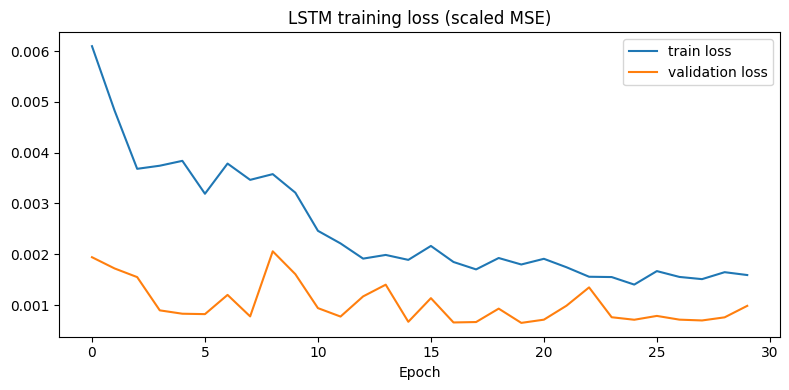

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('LSTM training loss (scaled MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Predict and convert back to dollars

Predictions are scaled, so they are placed in the Close column, the other columns are zero-filled, and the scaler is inverted. This is the same method as the README.

In [11]:
def inverse_close(scaled_close):
    dummy = np.zeros((len(scaled_close), scaler.n_features_in_))
    dummy[:, CLOSE_IDX] = scaled_close
    return scaler.inverse_transform(dummy)[:, CLOSE_IDX]

pred_scaled = model.predict(X_test, verbose=0).ravel()
y_pred = inverse_close(pred_scaled)
y_true = inverse_close(y_test)

# Naive baseline: today's Close (last timestep of each window) as tomorrow's prediction
y_baseline = inverse_close(X_test[:, -1, CLOSE_IDX])

## 6. Metrics

The LSTM should be compared against the naive baseline. An LSTM that does not beat the baseline is not adding much.

In [12]:
def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    return {
        'RMSE': float(np.sqrt(np.mean(err ** 2))),
        'MAE': float(np.mean(np.abs(err))),
        'MAPE_percent': float(np.mean(np.abs(err / y_true)) * 100),
    }

metrics = {
    'lstm': regression_metrics(y_true, y_pred),
    'naive_baseline': regression_metrics(y_true, y_baseline),
    'epochs_trained': len(history.history['loss']),
}

pd.DataFrame({
    'LSTM': metrics['lstm'],
    'Naive baseline': metrics['naive_baseline'],
}).T

,RMSE,MAE,MAPE_percent
LSTM,23.132113,18.049899,6.704150
Naive baseline,4.242868,2.920808,1.197558


In [13]:
with open(RESULTS / 'lstm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

## 7. Plot predictions on the test set

The last 591 rows of `test_scaled.csv` are the actual test days, so their dates line up with the predictions.

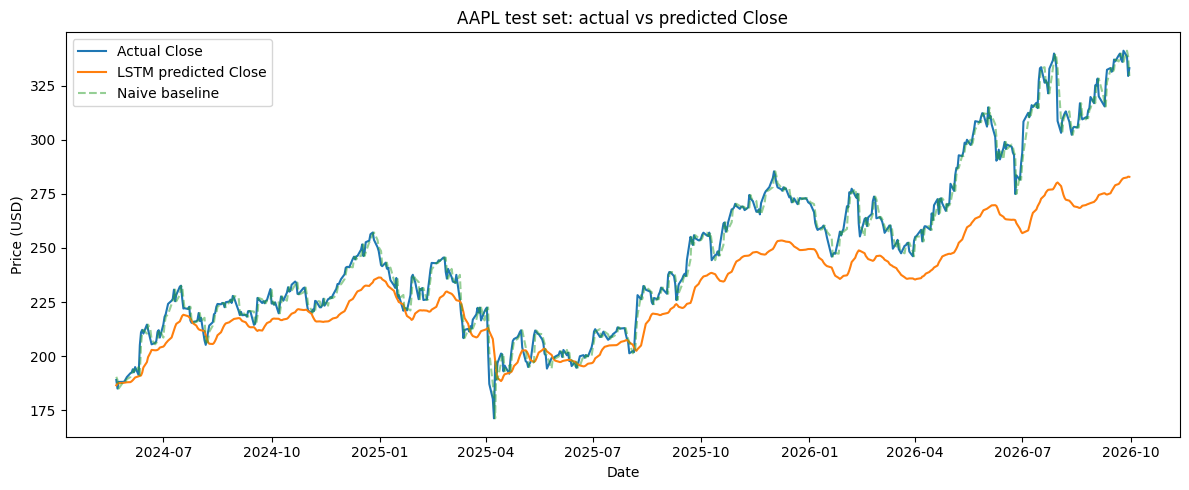

In [14]:
test_df = pd.read_csv(PROC / 'test_scaled.csv', parse_dates=['Date'])
dates = test_df['Date'].iloc[-len(y_test):].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(dates, y_true, label='Actual Close')
plt.plot(dates, y_pred, label='LSTM predicted Close')
plt.plot(dates, y_baseline, label='Naive baseline', alpha=0.5, linestyle='--')
plt.title('AAPL test set: actual vs predicted Close')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'lstm_predictions.png', dpi=150)
plt.show()

## 8. Save predictions and download results

In [15]:
pred_df = pd.DataFrame({
    'Date': dates,
    'Actual_Close': y_true,
    'Predicted_Close': y_pred,
})
pred_df.to_csv(RESULTS / 'lstm_predictions.csv', index=False)
pred_df.head()

,Date,Actual_Close,Predicted_Close
0,2024-05-22,189.097443,186.607030
1,2024-05-23,185.115433,187.369118
2,2024-05-24,188.186127,187.604736
3,2024-05-28,188.196045,187.726711
4,2024-05-29,188.493210,187.830258
